In [1]:
import numpy as np
import numpy.ma as ma
import scipy.sparse as sp
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from astropy.io import fits
from astropy.stats import sigma_clip
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.visualization import simple_norm
from astropy.wcs import WCS
from spectral_cube import SpectralCube as sc
from sklearn.cluster import DBSCAN
from tqdm.notebook import trange
import os
import warnings
from copy import deepcopy

np.seterr(divide="ignore", invalid="ignore")
np.set_printoptions(precision=10, suppress=True)
eps = 1e-12

#%matplotlib ipympl

In [2]:
file = "./HI4PI_E12_F12_merge.fits"
hdul = fits.open(file)
hdr = hdul[0].header
wcs = WCS(hdr)
wcsc = wcs.celestial
data = hdul[0].data.astype(np.float64)

In [3]:
cube = sc(data=data, wcs=wcs)
cube = cube.with_spectral_unit(u.km / u.s)

In [4]:
x1,y1 = wcsc.world_to_pixel(SkyCoord(234,14,frame="galactic",unit="deg"))
x2,y2 = wcsc.world_to_pixel(SkyCoord(229,14,frame="galactic",unit="deg"))
x3,y3 = wcsc.world_to_pixel(SkyCoord(229,4,frame="galactic",unit="deg"))
x4,y4 = wcsc.world_to_pixel(SkyCoord(229.75,4,frame="galactic",unit="deg"))
x5,y5 = wcsc.world_to_pixel(SkyCoord(234,11.25,frame="galactic",unit="deg"))

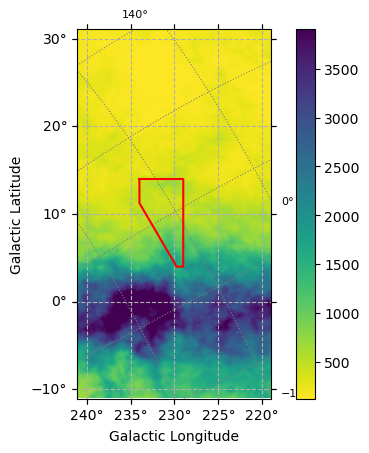

In [5]:
fig, ax = plt.subplots(1, 1, subplot_kw={"projection": wcsc})

moment_0 = np.array(cube.moment(order=0))
im = ax.imshow(moment_0, norm=simple_norm(moment_0, percent=95), cmap="viridis_r", origin="lower")
ax.grid(linestyle="--")
ax.set_xlabel("Galactic Longitude")
ax.set_ylabel("Galactic Latitude")
ax.plot([x1,x2,x3,x4,x5,x1], [y1,y2,y3,y4,y5,y1], color="red")

overlay = ax.get_coords_overlay("icrs")
overlay.grid(color="grey", ls="dotted")

overlay["ra"].set_ticks_position(("const-dec", "t"))
overlay["ra"].set_ticklabel(size=8)
overlay["ra"].set_ticks_visible(False)
overlay["dec"].set_axislabel("RA")
overlay["ra"].set_axislabel_visibility_rule("ticks")

overlay["dec"].add_tickable_gridline("const-dec", 0 * u.deg)
overlay["dec"].set_ticklabel(size=8)
overlay["dec"].set_ticks_visible(False)
overlay["dec"].set_axislabel("Dec")
overlay["dec"].set_axislabel_visibility_rule("ticks")

plt.colorbar(im)

In [6]:
y_height = data[0].shape[0]
x_width = data[0].shape[1]

x_indices, y_indices = np.meshgrid(np.arange(x_width), np.arange(y_height))

# Convert pixel indices to world coordinates
world_coords = wcsc.pixel_to_world(x_indices, y_indices)

# Extract the DEC values and store them in the coord_array
coord_array_dec = world_coords.icrs.dec.value
coord_array_l = world_coords.galactic.l.value
coord_array_b = world_coords.galactic.b.value

In [7]:
mask_dec = ma.masked_greater(coord_array_dec, -13).mask
mask_l1 = ma.masked_greater(coord_array_l, 229).mask
mask_l2 = ma.masked_less(coord_array_l, 234).mask
mask_b1 = ma.masked_greater(coord_array_b, 4).mask
mask_b2 = ma.masked_less(coord_array_b, 14).mask
mask = mask_dec * mask_l1 * mask_l2 * mask_b1 * mask_b2

In [8]:
masked_data = data * mask[np.newaxis, :, :]
masked_data.shape

(933, 506, 266)

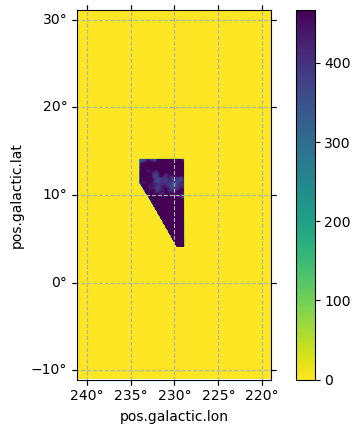

In [9]:
masked_cube = sc(data=masked_data, wcs=wcs)
masked_cube = masked_cube.with_spectral_unit(u.km / u.s)

fig, ax = plt.subplots(1, 1, subplot_kw={"projection": wcsc})

masked_moment_0 = np.array(masked_cube.moment(order=0))
masked_im = ax.imshow(masked_moment_0, norm=simple_norm(masked_moment_0, percent=95), cmap="viridis_r", origin="lower")
ax.grid(linestyle="--")

plt.colorbar(masked_im)

In [10]:
wcsc.world_to_pixel(SkyCoord(229,4,frame="galactic",unit="deg"))

(array(145.0000000048), array(180.000000072))

In [11]:
wcsc.world_to_pixel(SkyCoord(234,14,frame="galactic",unit="deg"))

(array(84.9999999808), array(300.00000012))

In [12]:
wcs

WCS Keywords

Number of WCS axes: 3
CTYPE : 'GLON-CAR' 'GLAT-CAR' 'VRAD' 
CRVAL : np.float64(230.0) np.float64(0.0) np.float64(0.0) 
CRPIX : np.float64(134.0) np.float64(133.0000000528) np.float64(466.921630003202) 
PC1_1 PC1_2 PC1_3  : np.float64(1.0) np.float64(0.0) np.float64(0.0) 
PC2_1 PC2_2 PC2_3  : np.float64(0.0) np.float64(1.0) np.float64(0.0) 
PC3_1 PC3_2 PC3_3  : np.float64(0.0) np.float64(0.0) np.float64(1.0) 
CDELT : np.float64(-0.0833333333) np.float64(0.0833333333) np.float64(1288.21496912415) 
NAXIS : 266  506  933

In [13]:
hdr_new = deepcopy(hdr)
hdr_new["CRPIX2"] -= 181
hdr_new["CRPIX1"] -= 85
wcs_new = WCS(hdr_new)

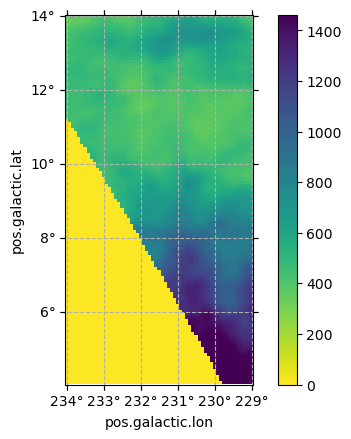

In [14]:
masked_data2 = masked_data[:, 181:301, 85:146]
masked_cube2 = sc(data=masked_data2, wcs=wcs_new)
masked_cube2 = masked_cube2.with_spectral_unit(u.km / u.s)

fig, ax = plt.subplots(1, 1, subplot_kw={"projection": wcs_new.celestial})

masked_moment_02 = np.array(masked_cube2.moment(order=0))
masked_im = ax.imshow(masked_moment_02, norm=simple_norm(masked_moment_02, percent=95), cmap="viridis_r", origin="lower")
ax.grid(linestyle="--")

plt.colorbar(masked_im)

In [15]:
x0, y0 = wcs_new.celestial.world_to_pixel(SkyCoord(231,10,frame="galactic",unit="deg"))
x0, y0, masked_data2[467 ,71, 36]

(array(35.9999999952), array(71.0000001008), np.float64(24.765106201171875))

In [16]:
hdu_new = fits.PrimaryHDU(data=masked_data2, header=hdr_new)
hdu_new.writeto('HI4PI_229_234_4_14.fits', overwrite=True)

In [20]:
crafts_cube = sc.read("../HVC_229_234_4_14.fits")
crafts_cube = crafts_cube.with_spectral_unit(u.km / u.s)
reprojected_cube = masked_cube2.reproject(crafts_cube.header)
reprojected_cube.write('./HI4PI_229_234_4_14_reproj.fits', format='fits', overwrite=True)